# 05 — YOLO Inference

Run inference using the trained YOLO26s model on unseen driving images and analyze the detected objects.

### Objectives
- Load the best trained YOLO26s model
- Run inference on unseen driving images
- Visualize object detections
- Extract bounding box information
- Analyze class labels and confidence scores
- Test different confidence thresholds
- Save inference results

### Project Roadmap
**Dataset Exploration → Data Preparation → YOLO Training → Evaluation → YOLO Inference → Driving Risk Analysis**

> **Current Stage:** YOLO Inference

## 1. Imports and Configuration

In [ ]:
# Required Libraries


# Path handling
from pathlib import Path

# Data handling
import pandas as pd

# Image processing and visualization
import matplotlib.pyplot as plt

# YOLO model
from ultralytics import YOLO

# Display images inside the notebook
from IPython.display import Image, display

%matplotlib inline

In [2]:
# Configuration

# Project paths
BEST_MODEL_PATH = Path("../runs/runs/yolo26s_main/weights/best.pt")

# Inference settings
IMG_SIZE = 512
CONF_THRESHOLD = 0.20
DEVICE = 0

In [3]:
print("Model path:", BEST_MODEL_PATH)
print("Model exists:", BEST_MODEL_PATH.exists())

Model path: ..\runs\runs\yolo26s_main\weights\best.pt
Model exists: True


## 2. Load the Best Trained Model



In [4]:
# Load the best trained YOLO26s model
model = YOLO(BEST_MODEL_PATH)

print("Best YOLO26s model loaded successfully.")

Best YOLO26s model loaded successfully.


In [5]:
model = YOLO(BEST_MODEL_PATH)

## 3. Load Test Images

In [6]:
# Path to the BDD100K test images
TEST_IMAGES_DIR = Path("../data/bdd100k/images/100k/test")

# Find all JPG images
test_images = list(TEST_IMAGES_DIR.glob("*.jpg"))

print("Number of test images:", len(test_images))

Number of test images: 20000


Selected image: cabc30fc-e7726578.jpg


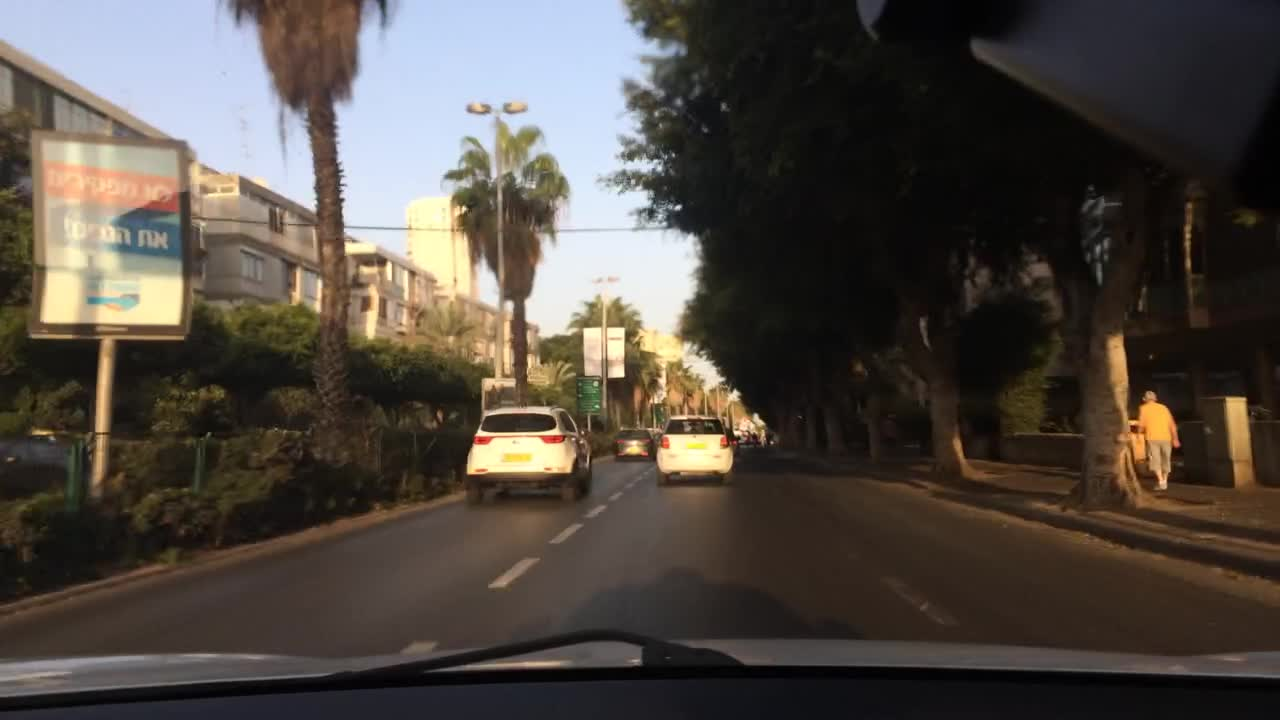

In [7]:
# Select the first test image
test_image = test_images[0]

print("Selected image:", test_image.name)

# Display the selected image
display(
    Image(
        filename=str(test_image),
        width=800
    )
)

## 4. Run YOLO Inference

In [8]:
# Run inference on the selected test image
results = model.predict(
    source=str(test_image),
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    device=DEVICE
)

print("Inference completed successfully.")


image 1/1 d:\Yasna-ML-Projects\Automotive-YOLO-Object-Detection\notebooks\..\data\bdd100k\images\100k\test\cabc30fc-e7726578.jpg: 288x512 3 cars, 1 person, 2 traffic signs, 60.3ms
Speed: 284.2ms preprocess, 60.3ms inference, 4.3ms postprocess per image at shape (1, 3, 288, 512)
Inference completed successfully.


## 5. Visualize Detection Results

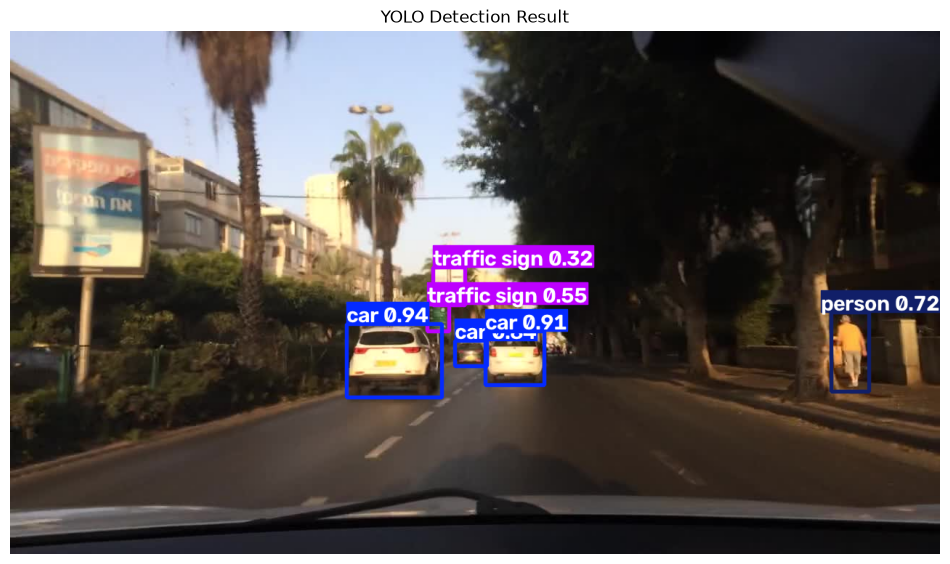

In [9]:
# Get the first inference result
result = results[0]

# Plot bounding boxes, class labels, and confidence scores
annotated_image = result.plot()

# Display the detection result
plt.figure(figsize=(12, 7))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("YOLO Detection Result")
plt.show()

## 6. Extract Detection Information

### 6.1 Bounding Boxes

In [10]:
# Extract bounding box coordinates
boxes = result.boxes.xyxy.cpu().numpy()

print("Number of detected objects:", len(boxes))
print("\nBounding boxes:")

for i, box in enumerate(boxes):
    x1, y1, x2, y2 = box

    print(
        f"Object {i + 1}: "
        f"x1={x1:.1f}, y1={y1:.1f}, "
        f"x2={x2:.1f}, y2={y2:.1f}"
    )

Number of detected objects: 6

Bounding boxes:
Object 1: x1=463.9, y1=403.6, x2=594.8, y2=504.9
Object 2: x1=654.9, y1=413.1, x2=735.5, y2=487.1
Object 3: x1=612.5, y1=426.7, x2=656.1, y2=461.9
Object 4: x1=1130.0, y1=387.6, x2=1182.4, y2=496.7
Object 5: x1=574.7, y1=376.5, x2=604.1, y2=413.8
Object 6: x1=582.3, y1=325.7, x2=626.2, y2=377.9


### 6.2 Class Labels

In [11]:
# Extract class IDs
class_ids = result.boxes.cls.cpu().numpy().astype(int)

# Get class names from the YOLO model
class_names = result.names

print("Detected classes:\n")

for i, class_id in enumerate(class_ids):
    print(f"Object {i + 1}: {class_names[class_id]}")

Detected classes:

Object 1: car
Object 2: car
Object 3: car
Object 4: person
Object 5: traffic sign
Object 6: traffic sign


### 6.3 Confidence Scores

In [12]:
# Extract confidence scores
confidence_scores = result.boxes.conf.cpu().numpy()

print("Confidence scores:\n")

for i, confidence in enumerate(confidence_scores):
    print(f"Object {i + 1}: {confidence:.3f}")

Confidence scores:

Object 1: 0.937
Object 2: 0.908
Object 3: 0.844
Object 4: 0.724
Object 5: 0.547
Object 6: 0.321


## 7. Confidence Threshold Analysis

In [13]:
CONF_THRESHOLD = 0.20

In [14]:
# Confidence thresholds to compare
thresholds = [0.20, 0.50, 0.80]

for threshold in thresholds:

    threshold_results = model.predict(
        source=str(test_image),
        imgsz=IMG_SIZE,
        conf=threshold,
        device=DEVICE,
        verbose=False
    )

    detection_count = len(threshold_results[0].boxes)

    print(
        f"Confidence threshold {threshold:.2f}: "
        f"{detection_count} detections"
    )

Confidence threshold 0.20: 6 detections
Confidence threshold 0.50: 5 detections
Confidence threshold 0.80: 3 detections


## 8. Inference on Multiple Images

In [15]:
# Select multiple test images
sample_images = test_images[:5]

print("Number of selected images:", len(sample_images))

# Run inference on multiple images
multiple_results = model.predict(
    source=[str(image) for image in sample_images],
    imgsz=IMG_SIZE,
    conf=CONF_THRESHOLD,
    device=DEVICE,
    verbose=False
)

print("Inference completed on multiple images.")

Number of selected images: 5
Inference completed on multiple images.


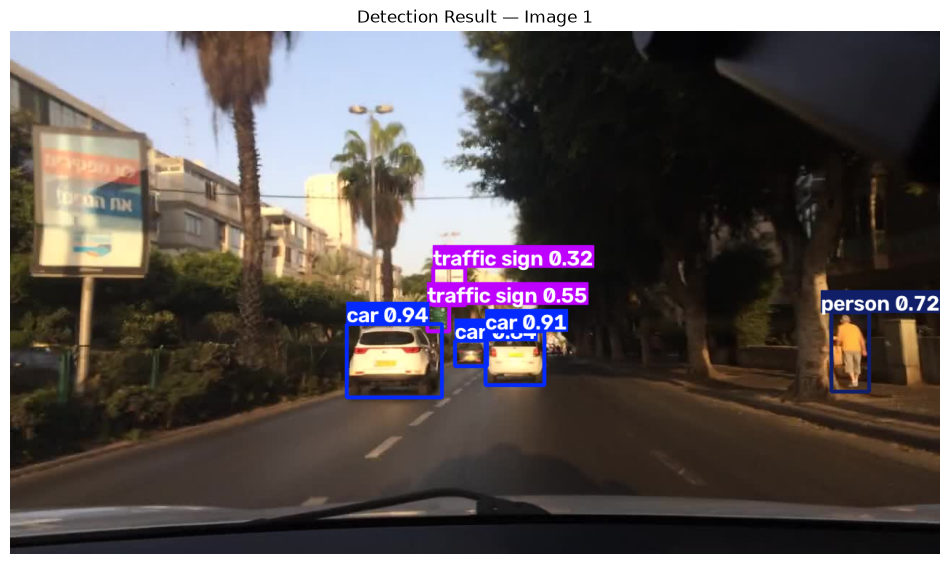

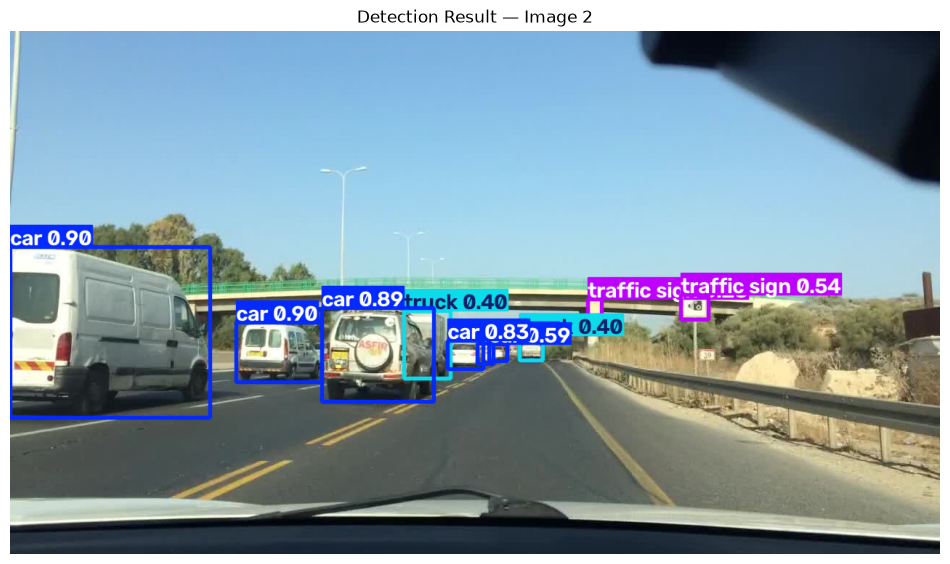

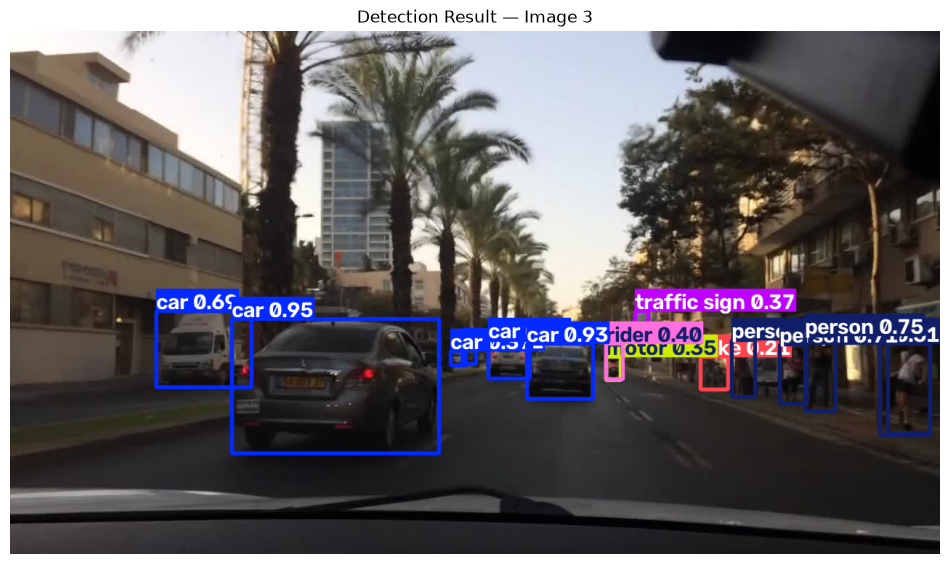

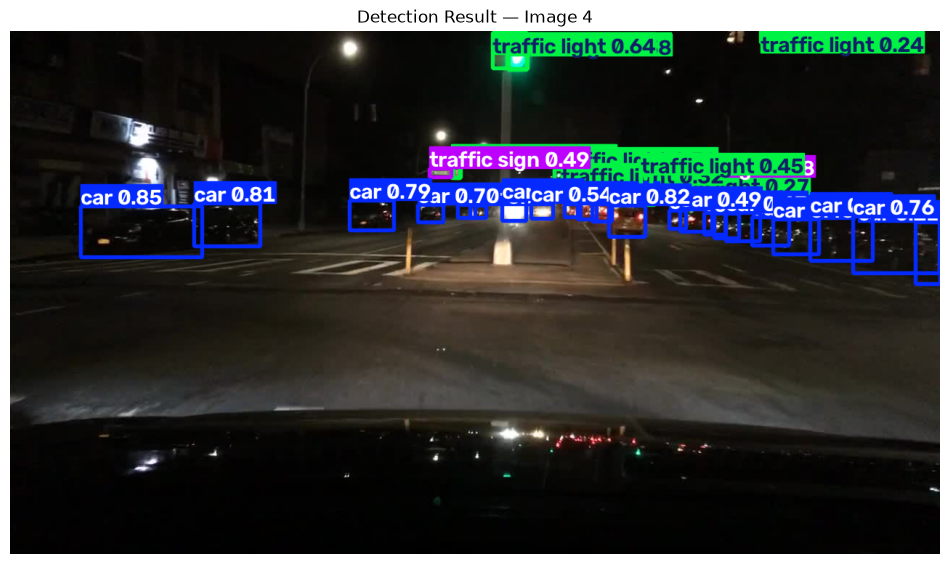

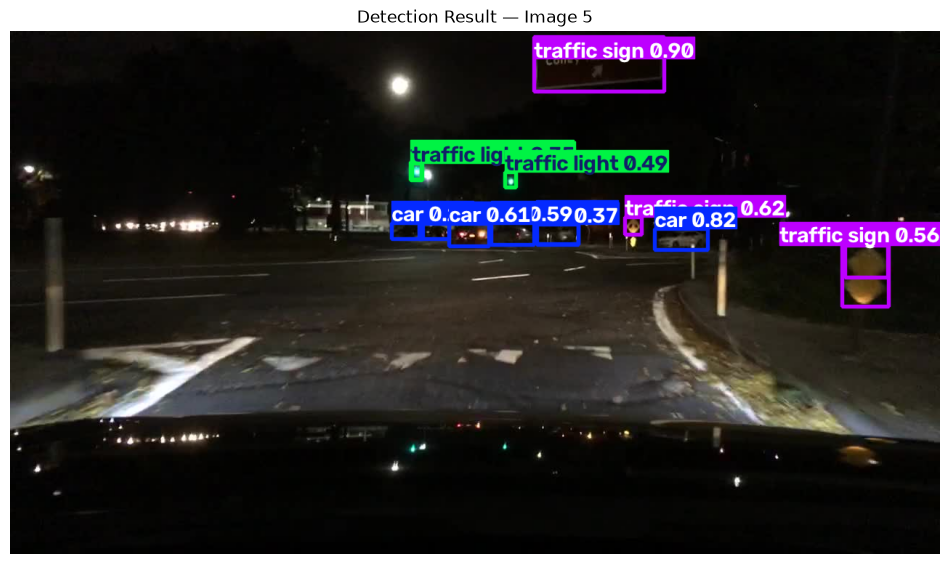

In [16]:
# Visualize inference results for multiple images
for i, result in enumerate(multiple_results):

    annotated_image = result.plot()

    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_image[:, :, ::-1])
    plt.axis("off")
    plt.title(f"Detection Result — Image {i + 1}")
    plt.show()
    

## 9. Save Inference Results


In [17]:
# Create an output directory for inference results
OUTPUT_DIR = Path("../outputs/inference")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: ..\outputs\inference


In [18]:
# Save annotated inference images
for i, result in enumerate(multiple_results):

    # Create the annotated image
    annotated_image = result.plot()

    # Define the output file path
    output_path = OUTPUT_DIR / f"inference_{i + 1}.jpg"

    # Save the image
    plt.imsave(
        output_path,
        annotated_image[:, :, ::-1]
    )

    print(f"Saved: {output_path}")

Saved: ..\outputs\inference\inference_1.jpg
Saved: ..\outputs\inference\inference_2.jpg
Saved: ..\outputs\inference\inference_3.jpg
Saved: ..\outputs\inference\inference_4.jpg
Saved: ..\outputs\inference\inference_5.jpg


## 10. Conclusion

The trained YOLO26s model was successfully used to perform inference on unseen images from the BDD100K test dataset.

### Key Outcomes

- The best trained YOLO26s model (`best.pt`) was successfully loaded and used for inference.
- Object detections were performed on unseen driving images.
- Bounding boxes, class labels, and confidence scores were visualized and extracted from the model predictions.
- Different confidence thresholds were tested to understand their effect on detection results.
- The model was successfully applied to multiple test images.
- Annotated inference results were saved for later analysis.

This inference pipeline demonstrates how the trained object detection model can be used to identify and locate road objects in new driving scenes.

### Next Step

**Driving Risk Analysis**

The detected objects, bounding box locations, class labels, and confidence scores will be used as the foundation for analyzing potential driving risks in road scenes.